# TP 2 — Ciencia de Datos
## Clasificación de intenciones (Intent Detection) con NLP

**Dataset:** `intent.csv` — 13.083 mensajes con 77 categorías de intención
**Fecha:** Mayo 2026
**Asignatura:** Ciencia de Datos 2026

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import string
import time
import warnings
from collections import Counter

from wordcloud import WordCloud
import nltk
from nltk.corpus import stopwords

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report, confusion_matrix)
from imblearn.over_sampling import SMOTE

warnings.filterwarnings('ignore')
nltk.download('stopwords', quiet=True)
stop_words = set(stopwords.words('english'))

# Estilo visual
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (12, 6)
pd.set_option('display.max_colwidth', 100)

## 1. Carga y revisión inicial del dataset

In [2]:
# Carga del dataset
df = pd.read_csv('intent.csv')

print(f'Dimensiones del dataset: {df.shape}')
print(f'\nColumnas: {df.columns.tolist()}')
print(f'\nTipos de datos:')
print(df.dtypes)
print(f'\nValores nulos por columna:')
print(df.isnull().sum())
print(f'\nCantidad de categorías únicas: {df["category"].nunique()}')

display(df.head(10))

Dimensiones del dataset: (13083, 2)

Columnas: ['text', 'category']

Tipos de datos:
text        str
category    str
dtype: object

Valores nulos por columna:
text        0
category    0
dtype: int64

Cantidad de categorías únicas: 77


,text,category
0,I am still waiting on my card?,card_arrival
1,What can I do if my card still hasn't arrived after 2 weeks?,card_arrival
2,I have been waiting over a week. Is the card still coming?,card_arrival
3,Can I track my card while it is in the process of delivery?,card_arrival
4,"How do I know if I will get my card, or if it is lost?",card_arrival
5,When did you send me my new card?,card_arrival
6,Do you have info about the card on delivery?,card_arrival
7,What do I do if I still have not received my new card?,card_arrival
8,Does the package with my card have tracking?,card_arrival
9,I ordered my card but it still isn't here,card_arrival


## Parte 1 — Análisis Exploratorio de Datos (EDA)

En esta sección se analizan:
- Distribución de categorías.
- Longitud de los textos.
- Palabras más frecuentes.
- Nubes de palabras por categoría.

### 1.1 Distribución de categorías

In [3]:
# Distribución de categorías
cat_counts = df['category'].value_counts()

print(f'Total de categorías: {len(cat_counts)}')
print(f'Muestras por clase — media: {cat_counts.mean():.1f}, '
      f'min: {cat_counts.min()}, max: {cat_counts.max()}')
print(f'Clases con <100 muestras: {(cat_counts < 100).sum()}')
print(f'Clases con <150 muestras: {(cat_counts < 150).sum()}')
print()
print('Top 10 categorías:')
display(cat_counts.head(10).to_frame('count'))
print('\nBottom 10 categorías:')
display(cat_counts.tail(10).to_frame('count'))

Total de categorías: 77
Muestras por clase — media: 169.9, min: 75, max: 227
Clases con <100 muestras: 3
Clases con <150 muestras: 17

Top 10 categorías:


,count
category,
card_payment_fee_charged,227
direct_debit_payment_not_recognised,222
balance_not_updated_after_cheque_or_cash_deposit,221
wrong_amount_of_cash_received,220
cash_withdrawal_charge,217
transaction_charged_twice,215
declined_cash_withdrawal,213
transfer_fee_charged,212
transfer_not_received_by_recipient,211



Bottom 10 categorías:


,count
category,
top_up_limits,137
get_disposable_virtual_card,137
receiving_money,135
atm_support,127
compromised_card,126
lost_or_stolen_card,122
card_swallowed,101
card_acceptance,99
virtual_card_not_working,81


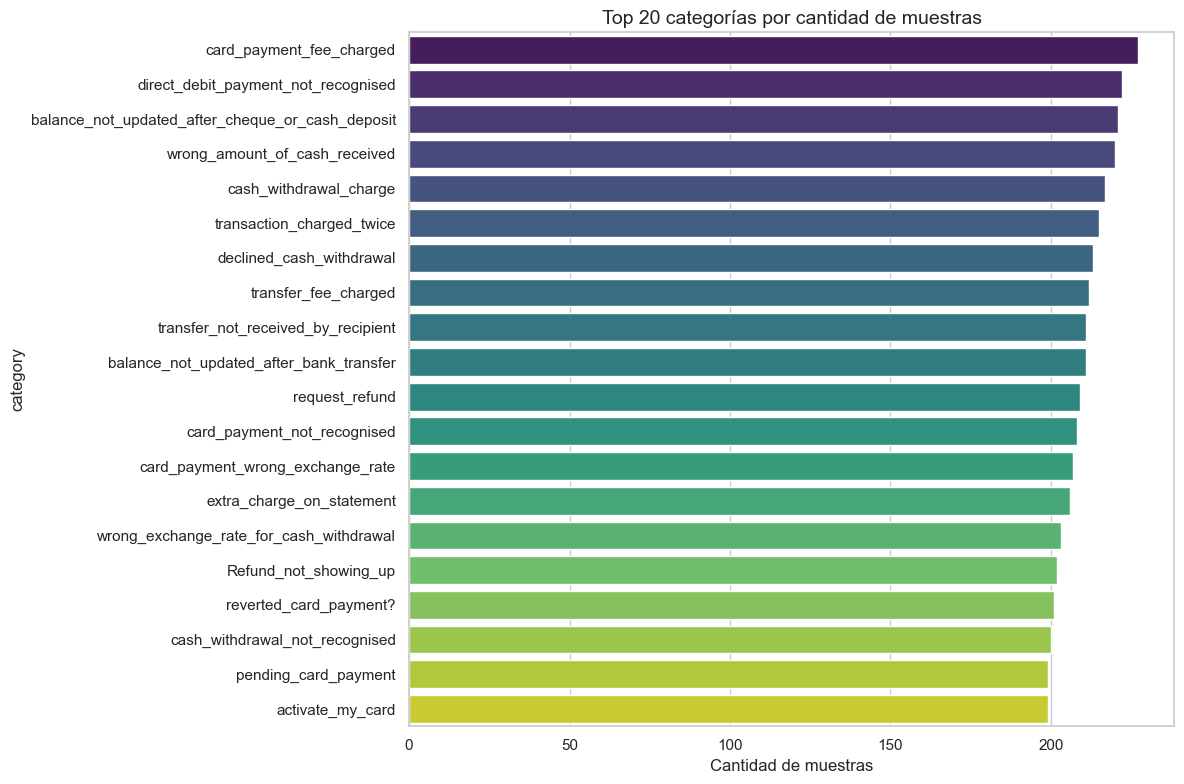

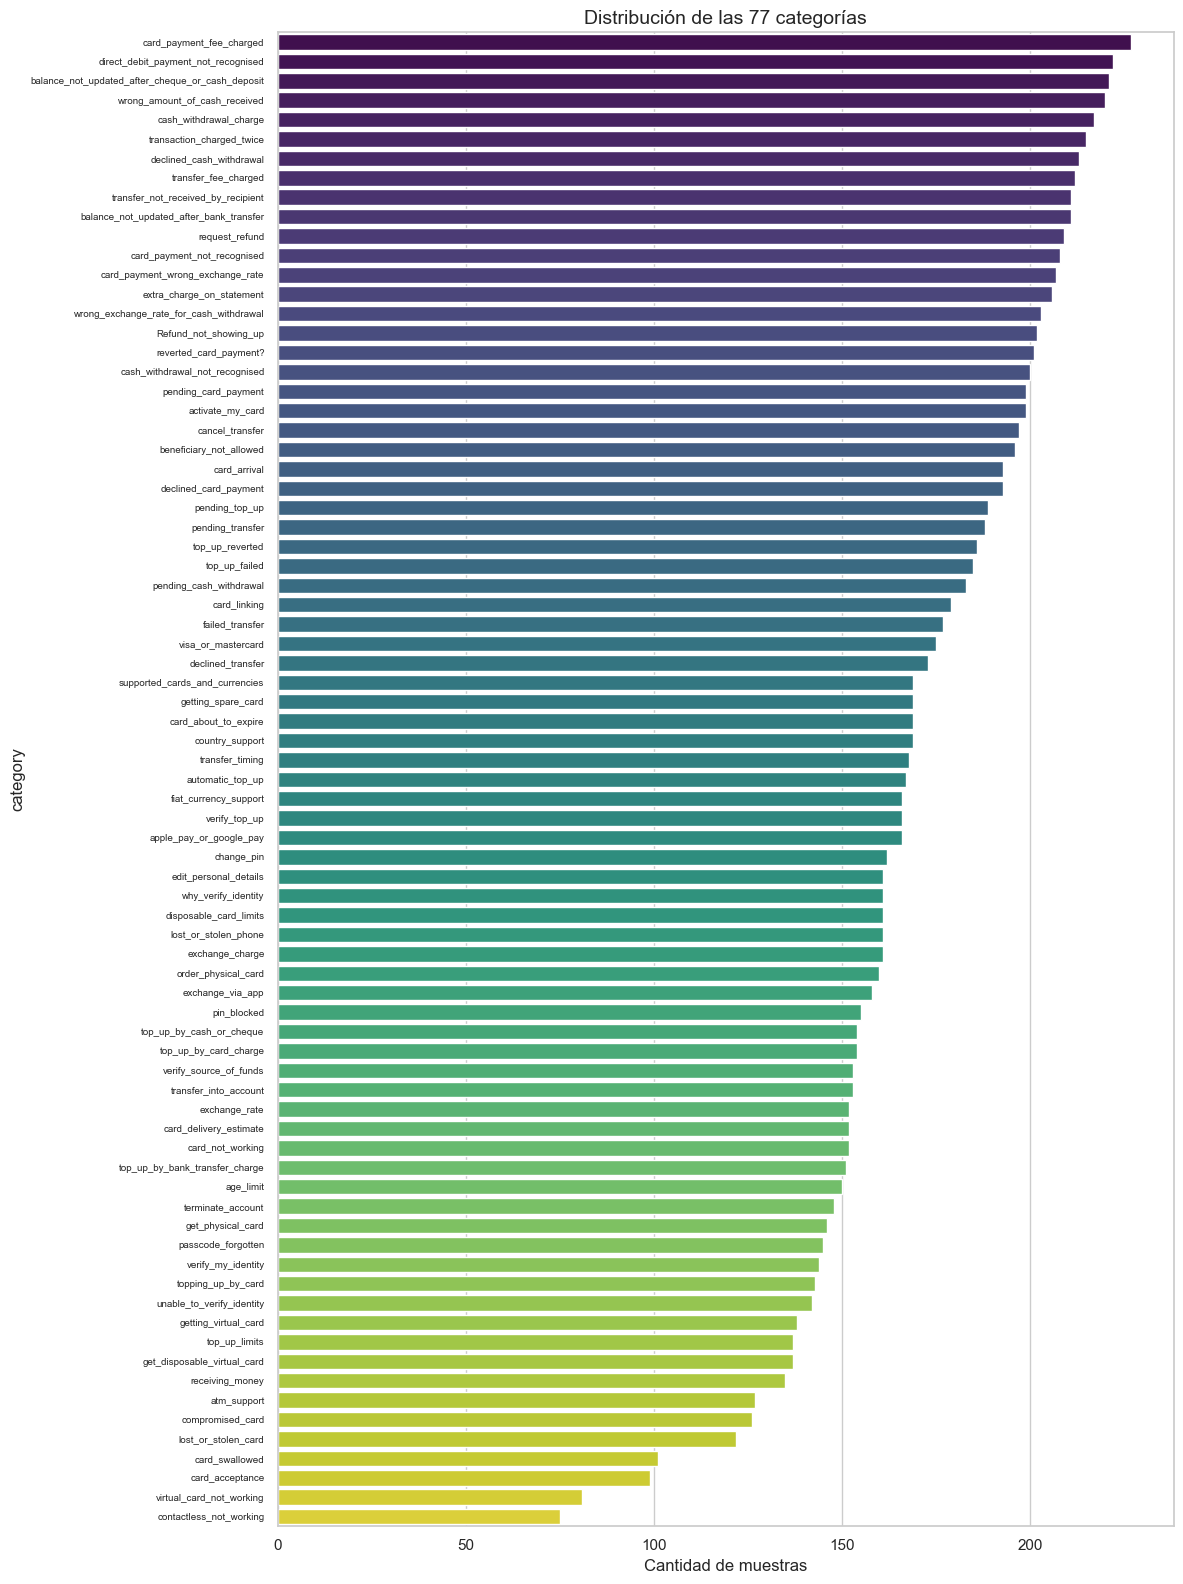

In [4]:
# Gráfico de distribución de categorías (top 20)
fig, ax = plt.subplots(figsize=(12, 8))
top20 = cat_counts.head(20)
sns.barplot(x=top20.values, y=top20.index, palette='viridis', ax=ax)
ax.set_title('Top 20 categorías por cantidad de muestras', fontsize=14)
ax.set_xlabel('Cantidad de muestras')
plt.tight_layout()
plt.show()

# Distribución completa
fig, ax = plt.subplots(figsize=(12, 16))
sns.barplot(x=cat_counts.values, y=cat_counts.index, palette='viridis', ax=ax)
ax.set_title('Distribución de las 77 categorías', fontsize=14)
ax.set_xlabel('Cantidad de muestras')
ax.tick_params(axis='y', labelsize=7)
plt.tight_layout()
plt.show()

### 1.2 Análisis de longitud de textos

In [5]:
# Longitud de texto (en caracteres y palabras)
df['text_len_chars'] = df['text'].str.len()
df['text_len_words'] = df['text'].str.split().str.len()

print('--- Longitud en caracteres ---')
print(df['text_len_chars'].describe().round(2))
print('\n--- Longitud en palabras ---')
print(df['text_len_words'].describe().round(2))

--- Longitud en caracteres ---
count    13083.00
mean        58.24
std         39.56
min         13.00
25%         36.00
50%         46.00
75%         63.00
max        433.00
Name: text_len_chars, dtype: float64

--- Longitud en palabras ---
count    13083.00
mean        11.71
std          7.64
min          2.00
25%          7.00
50%         10.00
75%         13.00
max         79.00
Name: text_len_words, dtype: float64


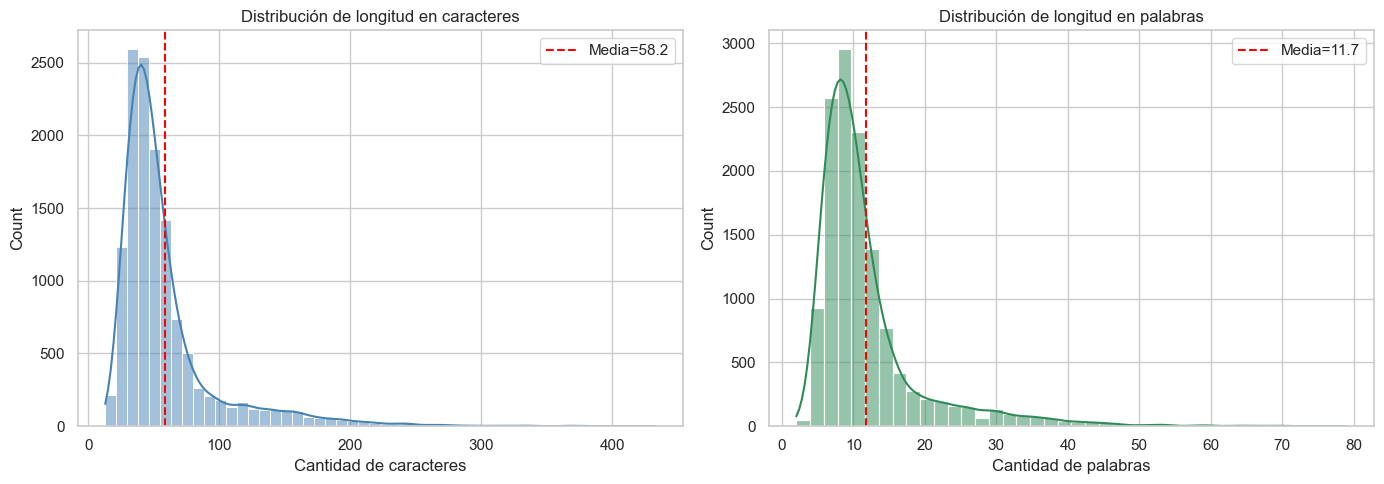

In [6]:
# Histogramas de longitud
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['text_len_chars'], bins=50, kde=True, ax=axes[0], color='steelblue')
axes[0].axvline(df['text_len_chars'].mean(), color='red', linestyle='--', label=f'Media={df["text_len_chars"].mean():.1f}')
axes[0].set_title('Distribución de longitud en caracteres')
axes[0].set_xlabel('Cantidad de caracteres')
axes[0].legend()

sns.histplot(df['text_len_words'], bins=40, kde=True, ax=axes[1], color='seagreen')
axes[1].axvline(df['text_len_words'].mean(), color='red', linestyle='--', label=f'Media={df["text_len_words"].mean():.1f}')
axes[1].set_title('Distribución de longitud en palabras')
axes[1].set_xlabel('Cantidad de palabras')
axes[1].legend()

plt.tight_layout()
plt.show()

### 1.3 Palabras más frecuentes (global)

In [7]:
# Text preprocessing for word frequency
def simple_clean(text):
    text = text.lower()
    text = ''.join([c for c in text if c not in string.punctuation])
    tokens = text.split()
    tokens = [w for w in tokens if w not in stop_words and len(w) > 2]
    return tokens

all_tokens = []
for text in df['text']:
    all_tokens.extend(simple_clean(text))

word_freq = Counter(all_tokens)
print(f'Total de tokens (post-limpieza): {len(all_tokens):,}')
print(f'Vocabulario único: {len(word_freq):,}')
print('\nTop 30 palabras más frecuentes:')
for word, count in word_freq.most_common(30):
    print(f'  {word}: {count}')

Total de tokens (post-limpieza): 68,055
Vocabulario único: 2,472

Top 30 palabras más frecuentes:
  card: 3576
  account: 1711
  money: 1404
  transfer: 1389
  get: 1045
  need: 927
  payment: 916
  cash: 883
  top: 809
  exchange: 708
  charged: 659
  please: 642
  atm: 612
  app: 611
  use: 579
  fee: 572
  pending: 543
  topup: 519
  help: 475
  pin: 459
  would: 456
  transaction: 456
  long: 450
  still: 448
  made: 434
  new: 432
  make: 427
  didnt: 422
  rate: 418
  take: 411


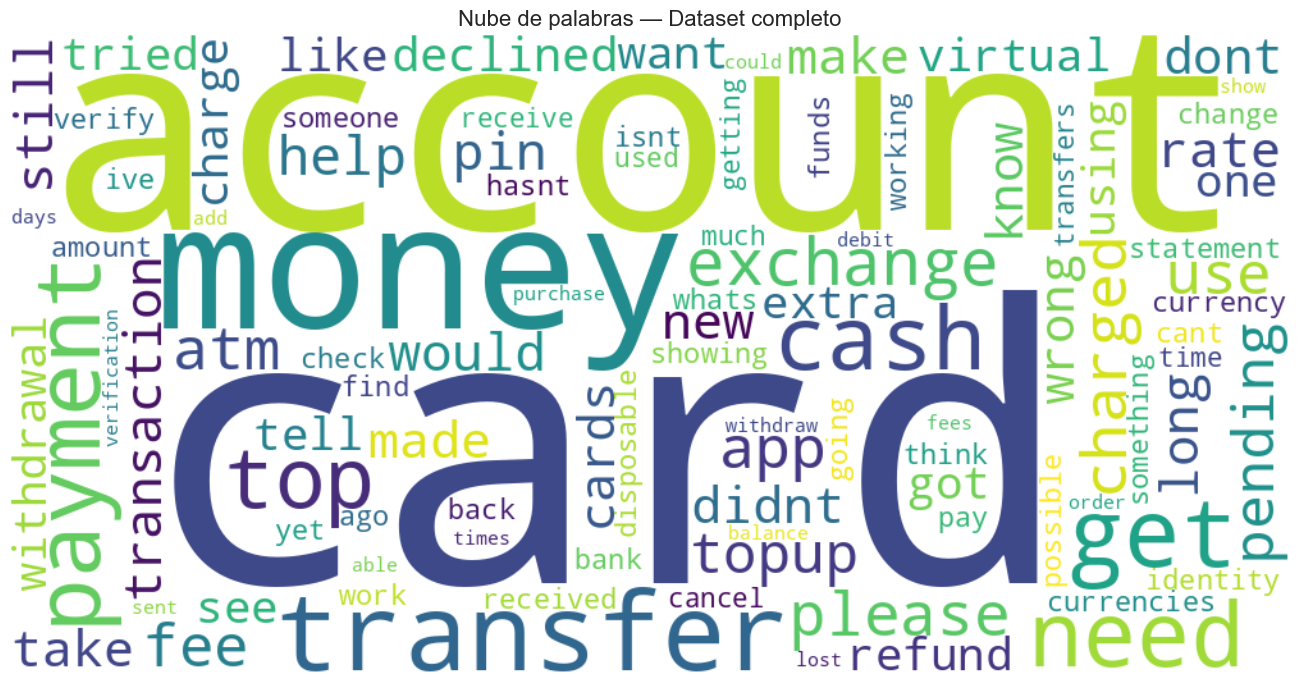

In [8]:
# Nube de palabras global
wordcloud = WordCloud(width=1000, height=500, background_color='white',
                      colormap='viridis', max_words=100,
                      stopwords=stop_words).generate_from_frequencies(word_freq)

fig, ax = plt.subplots(figsize=(14, 7))
ax.imshow(wordcloud, interpolation='bilinear')
ax.axis('off')
ax.set_title('Nube de palabras — Dataset completo', fontsize=16)
plt.tight_layout()
plt.show()

### 1.4 Nubes de palabras por categoría (top 6)

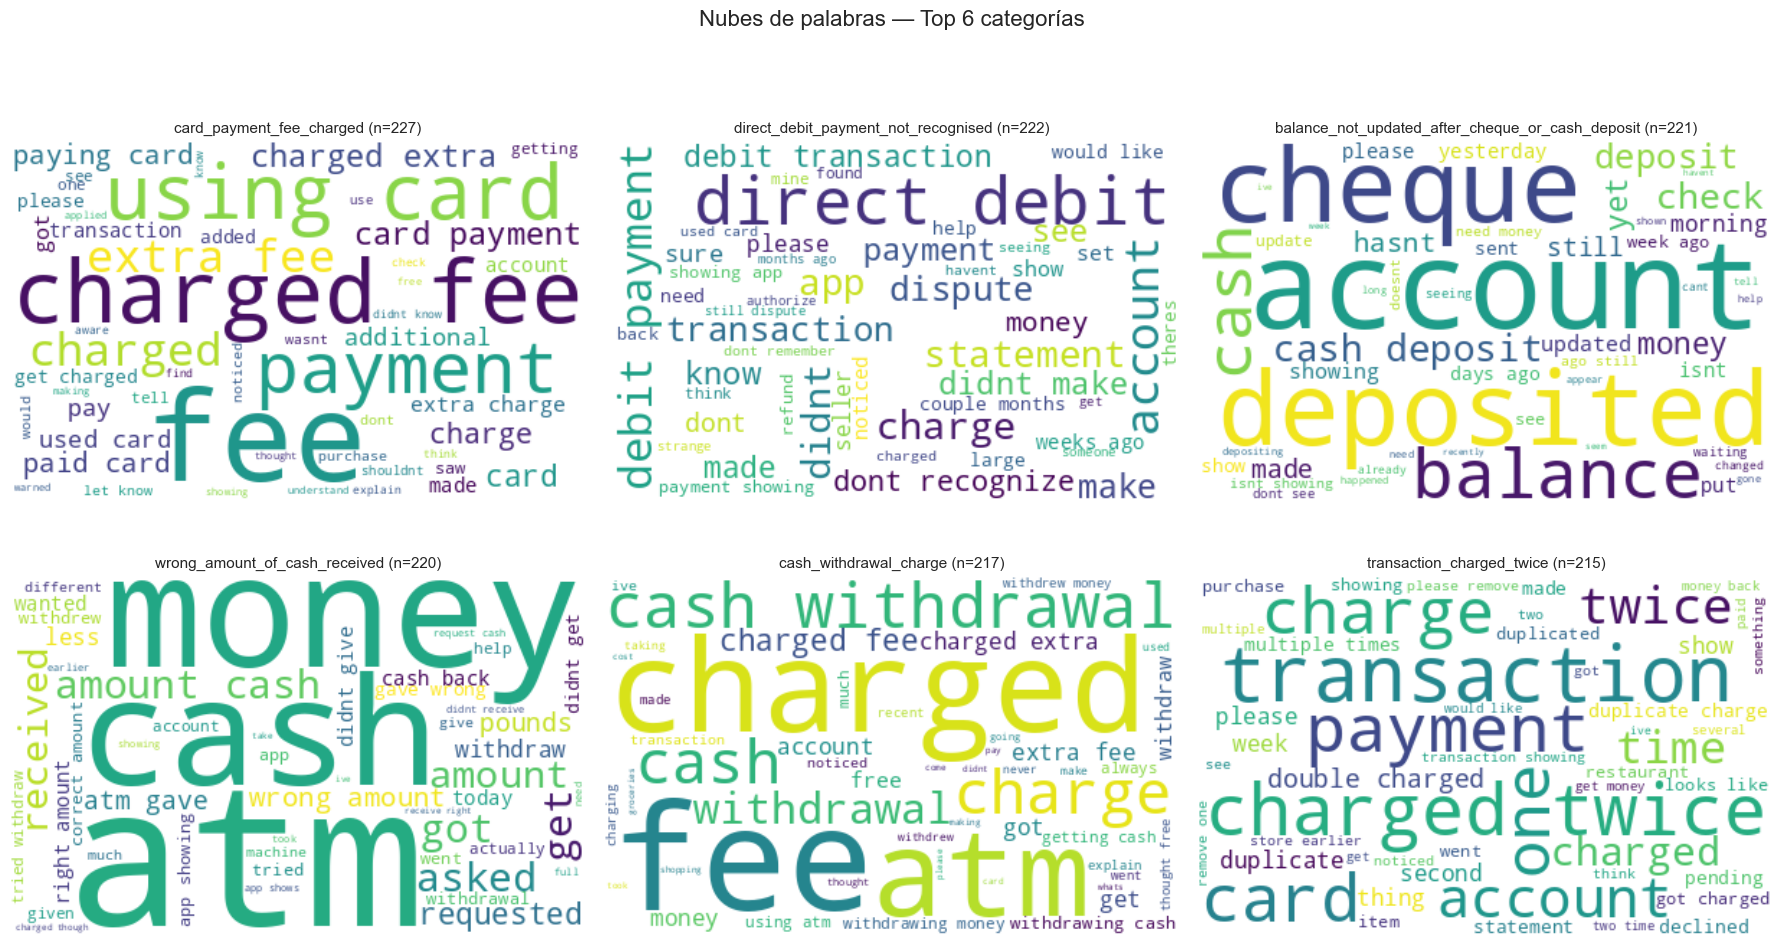

In [9]:
# Nubes de palabras para las 6 categorías más frecuentes
top6_cats = cat_counts.head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, cat in enumerate(top6_cats):
    cat_texts = df[df['category'] == cat]['text']
    tokens = []
    for text in cat_texts:
        tokens.extend(simple_clean(text))

    if tokens:
        wc = WordCloud(width=400, height=250, background_color='white',
                       colormap='viridis', max_words=50,
                       stopwords=stop_words).generate(' '.join(tokens))
        axes[i].imshow(wc, interpolation='bilinear')
        axes[i].set_title(f'{cat} (n={cat_counts[cat]})', fontsize=11)
    axes[i].axis('off')

plt.suptitle('Nubes de palabras — Top 6 categorías', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

## Parte 2 — Preprocesamiento para modelado

En esta sección se realiza:
- Limpieza de texto (lowercase, remoción de puntuación y stopwords).
- Codificación de la variable objetivo (LabelEncoder).
- Representación vectorial (BoW y TF-IDF).
- Balanceo de clases (SMOTE).
- División entrenamiento/prueba.

### 2.1 Limpieza de texto

In [10]:
# Función de limpieza de texto
def clean_text(text):
    text = text.lower()
    text = ''.join([char for char in text if char not in string.punctuation])
    tokens = text.split()
    tokens = [word for word in tokens if word not in stop_words and len(word) > 2]
    return ' '.join(tokens)

df['clean_text'] = df['text'].apply(clean_text)
print('Texto original vs limpio (5 ejemplos):')
for i in range(5):
    print(f'\n[{i}] Original: {df["text"].iloc[i][:80]}...')
    print(f'    Limpio:   {df["clean_text"].iloc[i][:80]}...')

Texto original vs limpio (5 ejemplos):

[0] Original: I am still waiting on my card?...
    Limpio:   still waiting card...

[1] Original: What can I do if my card still hasn't arrived after 2 weeks?...
    Limpio:   card still hasnt arrived weeks...

[2] Original: I have been waiting over a week. Is the card still coming?...
    Limpio:   waiting week card still coming...

[3] Original: Can I track my card while it is in the process of delivery?...
    Limpio:   track card process delivery...

[4] Original: How do I know if I will get my card, or if it is lost?...
    Limpio:   know get card lost...


### 2.2 Codificación de la variable objetivo

In [11]:
# Label encoding para las 77 categorías
le = LabelEncoder()
df['label'] = le.fit_transform(df['category'])

print(f'Clases codificadas: {len(le.classes_)}')
print(f'Mapeo de ejemplo (primeras 10):')
for i in range(10):
    print(f'  {le.classes_[i]} -> {i}')

y = df['label'].values
print(f'\nShape de y: {y.shape}')
print(f'Distribución de labels (value_counts):')
print(pd.Series(y).value_counts().describe())

Clases codificadas: 77
Mapeo de ejemplo (primeras 10):
  Refund_not_showing_up -> 0
  activate_my_card -> 1
  age_limit -> 2
  apple_pay_or_google_pay -> 3
  atm_support -> 4
  automatic_top_up -> 5
  balance_not_updated_after_bank_transfer -> 6
  balance_not_updated_after_cheque_or_cash_deposit -> 7
  beneficiary_not_allowed -> 8
  cancel_transfer -> 9

Shape de y: (13083,)
Distribución de labels (value_counts):
count     77.000000
mean     169.909091
std       32.942207
min       75.000000
25%      152.000000
50%      167.000000
75%      199.000000
max      227.000000
Name: count, dtype: float64


### 2.3 Representación vectorial: Bag of Words y TF-IDF

In [12]:
# Bag of Words (CountVectorizer)
print('Generando representación BoW...')
bow_vectorizer = CountVectorizer(max_features=3000)
X_bow = bow_vectorizer.fit_transform(df['clean_text'])
print(f'BoW shape: {X_bow.shape}')
print(f'Vocabulario BoW: {len(bow_vectorizer.vocabulary_)} términos')

Generando representación BoW...
BoW shape: (13083, 2471)
Vocabulario BoW: 2471 términos


In [13]:
# TF-IDF
print('Generando representación TF-IDF...')
tfidf_vectorizer = TfidfVectorizer(max_features=3000)
X_tfidf = tfidf_vectorizer.fit_transform(df['clean_text'])
print(f'TF-IDF shape: {X_tfidf.shape}')
print(f'Vocabulario TF-IDF: {len(tfidf_vectorizer.vocabulary_)} términos')

# Mostrar algunas features con mayor IDF (más discriminativas)
idf_scores = dict(zip(tfidf_vectorizer.get_feature_names_out(),
                       tfidf_vectorizer.idf_))
top_idf = sorted(idf_scores.items(), key=lambda x: x[1], reverse=True)[:15]
print('\nTop 15 términos con mayor IDF (más raros, más discriminativos):')
for term, score in top_idf:
    print(f'  {term}: {score:.2f}')

Generando representación TF-IDF...
TF-IDF shape: (13083, 2471)
Vocabulario TF-IDF: 2471 términos

Top 15 términos con mayor IDF (más raros, más discriminativos):
  10000: 9.79
  1818: 9.79
  1st: 9.79
  200000: 9.79
  7000: 9.79
  accessible: 9.79
  accommodated: 9.79
  accountcould: 9.79
  accounting: 9.79
  accountthis: 9.79
  accountwhat: 9.79
  accpeted: 9.79
  achieve: 9.79
  acount: 9.79
  acquire: 9.79


### 2.3.3 Sentence Embeddings (Sentence-BERT)

Como representación adicional, se generan embeddings densos con
`all-MiniLM-L6-v2` (384 dimensiones). La limpieza es más
ligera (sin remover stopwords) para preservar estructura sintáctica.

In [14]:
from sentence_transformers import SentenceTransformer

# Limpieza ligera para embeddings
def clean_for_embedding(text):
    text = text.lower()
    text = ''.join([c for c in text if c not in string.punctuation])
    return text

df['clean_text_emb'] = df['text'].apply(clean_for_embedding)

# Generar embeddings
print('Generando embeddings con all-MiniLM-L6-v2 ...')
embedder = SentenceTransformer('all-MiniLM-L6-v2')
X_embed = embedder.encode(df['clean_text_emb'].tolist(), show_progress_bar=True)
print(f'Embeddings shape: {X_embed.shape}  (dense, float32)')

Generando embeddings con all-MiniLM-L6-v2 ...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/409 [00:00<?, ?it/s]

Embeddings shape: (13083, 384)  (dense, float32)


### 2.4 División entrenamiento/prueba (antes de cualquier transformación)

Para evitar **data leakage**, se divide el dataset **antes** de ajustar vectorizadores o aplicar SMOTE.

- Train (70 %) y test (30 %) estratificados.
- El test conserva la distribución original desbalanceada.
- SMOTE y el ajuste de vectorizadores se harán **solo con train**.


In [15]:
# División estratificada ANTES de vectorizar o balancear
from sklearn.model_selection import train_test_split

# Usamos los textos limpios y las etiquetas ya codificadas
X_text_train, X_text_test, y_train, y_test = train_test_split(
    df['clean_text'], y, test_size=0.30, random_state=42, stratify=y
)

# Para embeddings usamos el texto con limpieza ligera
X_text_emb_train, X_text_emb_test = train_test_split(
    df['clean_text_emb'], test_size=0.30, random_state=42, stratify=y
)

print(f'Train: {len(X_text_train)} muestras')
print(f'Test:  {len(X_text_test)} muestras')
print(f'Distribución original en test (desbalanceada):')
print(f'  min={np.bincount(y_test).min()}, max={np.bincount(y_test).max()}')


Train: 9158 muestras
Test:  3925 muestras
Distribución original en test (desbalanceada):
  min=22, max=68


### 2.5 Vectorización: ajuste solo en train

In [16]:
# BoW: fit en train, transform en train y test
bow_vectorizer = CountVectorizer(max_features=3000)
X_bow_train = bow_vectorizer.fit_transform(X_text_train)
X_bow_test  = bow_vectorizer.transform(X_text_test)
print(f'BoW train: {X_bow_train.shape}, BoW test: {X_bow_test.shape}')

# TF-IDF: fit en train, transform en train y test
tfidf_vectorizer = TfidfVectorizer(max_features=3000)
X_tfidf_train = tfidf_vectorizer.fit_transform(X_text_train)
X_tfidf_test  = tfidf_vectorizer.transform(X_text_test)
print(f'TF-IDF train: {X_tfidf_train.shape}, TF-IDF test: {X_tfidf_test.shape}')

idf_scores = dict(zip(tfidf_vectorizer.get_feature_names_out(),
                       tfidf_vectorizer.idf_))
top_idf = sorted(idf_scores.items(), key=lambda x: x[1], reverse=True)[:15]
print('\nTop 15 términos con mayor IDF (aprendidos solo en train):')
for term, score in top_idf:
    print(f'  {term}: {score:.2f}')


BoW train: (9158, 2126), BoW test: (3925, 2126)
TF-IDF train: (9158, 2126), TF-IDF test: (3925, 2126)

Top 15 términos con mayor IDF (aprendidos solo en train):
  10000: 9.43
  1818: 9.43
  1st: 9.43
  200000: 9.43
  accessible: 9.43
  accommodated: 9.43
  accountcould: 9.43
  accounting: 9.43
  accpeted: 9.43
  achieve: 9.43
  acount: 9.43
  acquiring: 9.43
  across: 9.43
  acting: 9.43
  actions: 9.43


### 2.6 Sentence Embeddings

In [17]:
from sentence_transformers import SentenceTransformer

embedder = SentenceTransformer('all-MiniLM-L6-v2')
print('Generando embeddings...')
X_embed = embedder.encode(df['clean_text_emb'].tolist(), show_progress_bar=True)

# Aplicamos la misma máscara de split (índices)
train_idx, test_idx = train_test_split(
    np.arange(len(y)), test_size=0.30, random_state=42, stratify=y
)
X_emb_train, X_emb_test = X_embed[train_idx], X_embed[test_idx]
y_emb_train, y_emb_test = y[train_idx], y[test_idx]

print(f'Embeddings train: {X_emb_train.shape}, test: {X_emb_test.shape}')


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Generando embeddings...


Batches:   0%|          | 0/409 [00:00<?, ?it/s]

Embeddings train: (9158, 384), test: (3925, 384)


### 2.7 Balanceo con SMOTE **solo en train**

SMOTE genera muestras sintéticas únicamente sobre el conjunto de entrenamiento. El test queda con su distribución real y desbalanceada.

In [18]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42, k_neighbors=4)

# Solo train
X_bow_train_bal,   y_bow_train_bal   = smote.fit_resample(X_bow_train, y_train)
X_tfidf_train_bal, y_tfidf_train_bal = smote.fit_resample(X_tfidf_train, y_train)
X_emb_train_bal,   y_emb_train_bal   = smote.fit_resample(X_emb_train, y_emb_train)

print('Distribución post-SMOTE en train:')
print(f'  BoW:   min={np.bincount(y_bow_train_bal).min()}, max={np.bincount(y_bow_train_bal).max()}')
print(f'  TF-IDF: min={np.bincount(y_tfidf_train_bal).min()}, max={np.bincount(y_tfidf_train_bal).max()}')
print(f'  Embeddings: min={np.bincount(y_emb_train_bal).min()}, max={np.bincount(y_emb_train_bal).max()}')

print('\nDistribución real en test (sin SMOTE):')
print(f'  min={np.bincount(y_test).min()}, max={np.bincount(y_test).max()}')


Distribución post-SMOTE en train:
  BoW:   min=159, max=159
  TF-IDF: min=159, max=159
  Embeddings: min=159, max=159

Distribución real en test (sin SMOTE):
  min=22, max=68


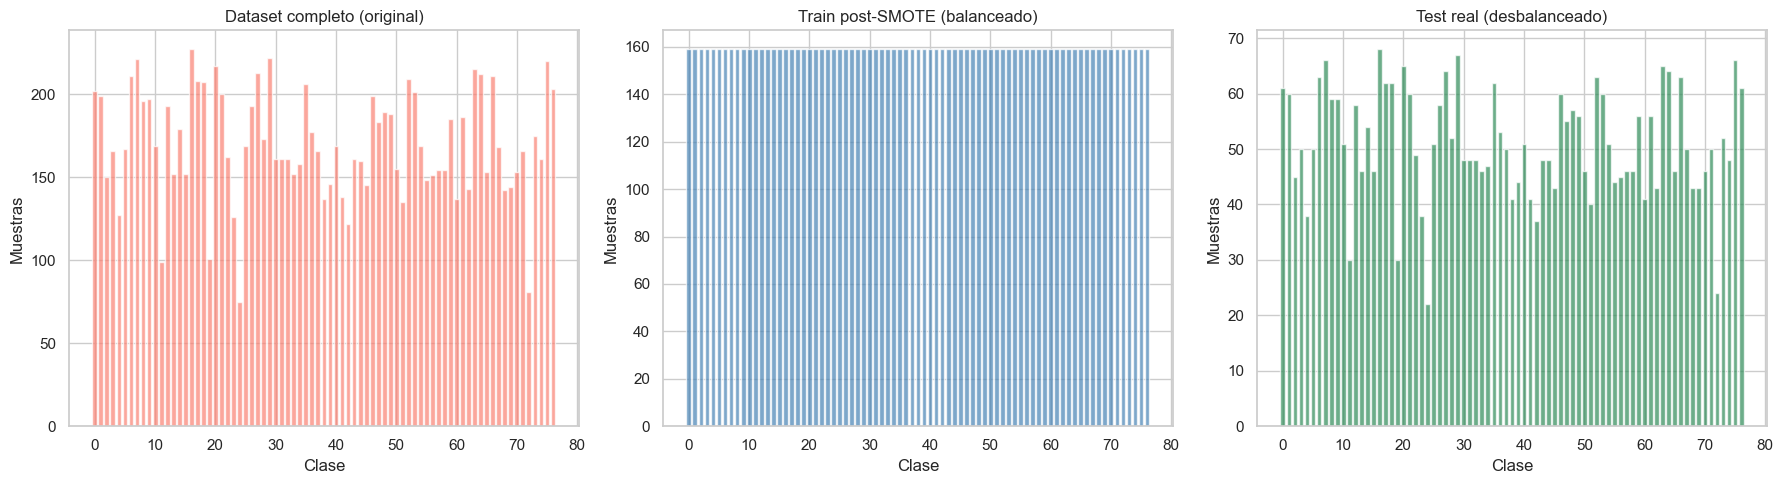

In [19]:
# Visualizar distribución original vs train balanceado vs test real
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].bar(range(77), np.bincount(y), color='salmon', alpha=0.7)
axes[0].set_title('Dataset completo (original)')
axes[0].set_xlabel('Clase'); axes[0].set_ylabel('Muestras')

axes[1].bar(range(77), np.bincount(y_bow_train_bal), color='steelblue', alpha=0.7)
axes[1].set_title('Train post-SMOTE (balanceado)')
axes[1].set_xlabel('Clase'); axes[1].set_ylabel('Muestras')

axes[2].bar(range(77), np.bincount(y_test), color='seagreen', alpha=0.7)
axes[2].set_title('Test real (desbalanceado)')
axes[2].set_xlabel('Clase'); axes[2].set_ylabel('Muestras')

plt.tight_layout()
plt.show()


## Parte 3 — Modelado y Evaluación

Se entrenan 3 modelos con `GridSearchCV`. SMOTE se coloca **dentro del pipeline** de cada fold: se aplica solo al sub-conjunto de entrenamiento de ese fold, mientras el sub-conjunto de validación permanece sin balancear.

In [20]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report)
from imblearn.pipeline import Pipeline as ImbPipeline
import time

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# Para representaciones dispersas (BoW / TF-IDF)
models_sparse = {
    'Logistic Regression': {
        'pipeline': ImbPipeline([
            ('smote', SMOTE(random_state=42, k_neighbors=4)),
            ('clf', LogisticRegression(max_iter=1000, random_state=42))
        ]),
        'params': {
            'clf__C': [0.1, 1, 10],
            'clf__solver': ['lbfgs'],
        }
    },
    'Naive Bayes': {
        'pipeline': ImbPipeline([
            ('smote', SMOTE(random_state=42, k_neighbors=4)),
            ('clf', MultinomialNB())
        ]),
        'params': {
            'clf__alpha': [0.01, 0.1, 0.5, 1.0],
        }
    },
    'Random Forest': {
        'pipeline': ImbPipeline([
            ('smote', SMOTE(random_state=42, k_neighbors=4)),
            ('clf', RandomForestClassifier(random_state=42))
        ]),
        'params': {
            'clf__n_estimators': [100, 200],
            'clf__max_depth': [30, None],
            'clf__min_samples_split': [2, 5],
        }
    },
}

# Para embeddings densos (no se usa MultinomialNB porque permite negativos)
from sklearn.naive_bayes import GaussianNB

models_emb = {
    'Logistic Regression': {
        'pipeline': ImbPipeline([
            ('smote', SMOTE(random_state=42, k_neighbors=4)),
            ('clf', LogisticRegression(max_iter=1000, random_state=42))
        ]),
        'params': {
            'clf__C': [0.1, 1, 10],
            'clf__solver': ['lbfgs'],
        }
    },
    'Naive Bayes': {
        'pipeline': ImbPipeline([
            ('smote', SMOTE(random_state=42, k_neighbors=4)),
            ('clf', GaussianNB())
        ]),
        'params': {
            'clf__var_smoothing': [1e-12, 1e-9, 1e-6],
        }
    },
    'Random Forest': {
        'pipeline': ImbPipeline([
            ('smote', SMOTE(random_state=42, k_neighbors=4)),
            ('clf', RandomForestClassifier(random_state=42))
        ]),
        'params': {
            'clf__n_estimators': [100, 200],
            'clf__max_depth': [30, None],
            'clf__min_samples_split': [2, 5],
        }
    },
}

print('Pipelines definidos. SMOTE queda dentro de cada fold de CV.')


Pipelines definidos. SMOTE queda dentro de cada fold de CV.


In [21]:
# Función de entrenamiento/evaluación corregida
def train_and_evaluate_correct(X_train, X_test, y_train, y_test, model_dict, vec_name):
    print(f'\n{"="*70}')
    print(f'  RESULTADOS CON {vec_name}')
    print(f'{"="*70}')

    results = []
    for name, mp in model_dict.items():
        print(f'\n--- {name} ---')
        t0 = time.time()

        gs = GridSearchCV(mp['pipeline'], mp['params'], cv=cv,
                          scoring='f1_macro', n_jobs=-1, verbose=0)
        gs.fit(X_train, y_train)

        best = gs.best_estimator_
        y_pred = best.predict(X_test)

        acc = accuracy_score(y_test, y_pred)
        f1w = f1_score(y_test, y_pred, average='weighted', zero_division=0)
        f1m = f1_score(y_test, y_pred, average='macro', zero_division=0)

        print(f'  Mejores hiperparámetros: {gs.best_params_}')
        print(f'  Accuracy:      {acc:.4f}')
        print(f'  F1 weighted:   {f1w:.4f}')
        print(f'  F1 macro:      {f1m:.4f}')
        print(f'  Tiempo:        {time.time()-t0:.1f}s')

        results.append({
            'Modelo': name,
            'Vectorización': vec_name,
            'Accuracy': round(acc, 4),
            'F1 (weighted)': round(f1w, 4),
            'F1 (macro)': round(f1m, 4),
            'Best Params': str(gs.best_params_),
        })
    return results


In [22]:
# BoW
results_bow = train_and_evaluate_correct(
    X_bow_train, X_bow_test, y_train, y_test, models_sparse, 'Bag of Words'
)



  RESULTADOS CON Bag of Words

--- Logistic Regression ---
  Mejores hiperparámetros: {'clf__C': 10, 'clf__solver': 'lbfgs'}
  Accuracy:      0.8538
  F1 weighted:   0.8547
  F1 macro:      0.8539
  Tiempo:        13.0s

--- Naive Bayes ---
  Mejores hiperparámetros: {'clf__alpha': 0.1}
  Accuracy:      0.8525
  F1 weighted:   0.8524
  F1 macro:      0.8501
  Tiempo:        2.6s

--- Random Forest ---
  Mejores hiperparámetros: {'clf__max_depth': None, 'clf__min_samples_split': 5, 'clf__n_estimators': 200}
  Accuracy:      0.8283
  F1 weighted:   0.8300
  F1 macro:      0.8283
  Tiempo:        24.3s


In [23]:
# TF-IDF
results_tfidf = train_and_evaluate_correct(
    X_tfidf_train, X_tfidf_test, y_train, y_test, models_sparse, 'TF-IDF'
)



  RESULTADOS CON TF-IDF

--- Logistic Regression ---
  Mejores hiperparámetros: {'clf__C': 10, 'clf__solver': 'lbfgs'}
  Accuracy:      0.8662
  F1 weighted:   0.8666
  F1 macro:      0.8657
  Tiempo:        9.8s

--- Naive Bayes ---
  Mejores hiperparámetros: {'clf__alpha': 0.5}
  Accuracy:      0.8482
  F1 weighted:   0.8481
  F1 macro:      0.8448
  Tiempo:        2.4s

--- Random Forest ---
  Mejores hiperparámetros: {'clf__max_depth': None, 'clf__min_samples_split': 5, 'clf__n_estimators': 200}
  Accuracy:      0.8395
  F1 weighted:   0.8398
  F1 macro:      0.8385
  Tiempo:        24.0s


In [24]:
# Embeddings
results_emb = train_and_evaluate_correct(
    X_emb_train, X_emb_test, y_emb_train, y_emb_test, models_emb, 'Embeddings'
)



  RESULTADOS CON Embeddings

--- Logistic Regression ---
  Mejores hiperparámetros: {'clf__C': 10, 'clf__solver': 'lbfgs'}
  Accuracy:      0.9282
  F1 weighted:   0.9285
  F1 macro:      0.9293
  Tiempo:        16.7s

--- Naive Bayes ---
  Mejores hiperparámetros: {'clf__var_smoothing': 1e-12}
  Accuracy:      0.8678
  F1 weighted:   0.8696
  F1 macro:      0.8733
  Tiempo:        3.0s

--- Random Forest ---
  Mejores hiperparámetros: {'clf__max_depth': None, 'clf__min_samples_split': 5, 'clf__n_estimators': 200}
  Accuracy:      0.9075
  F1 weighted:   0.9077
  F1 macro:      0.9091
  Tiempo:        157.7s


In [25]:
# Consolidar y guardar
all_results = pd.DataFrame(results_bow + results_tfidf + results_emb)
display(all_results.sort_values('F1 (macro)', ascending=False))
all_results.to_csv('resultados_modelos_corregidos.csv', index=False)
print('\nResultados guardados en resultados_modelos_corregidos.csv')


,Modelo,Vectorización,Accuracy,F1 (weighted),F1 (macro),Best Params
6,Logistic Regression,Embeddings,0.9282,0.9285,0.9293,"{'clf__C': 10, 'clf__solver': 'lbfgs'}"
8,Random Forest,Embeddings,0.9075,0.9077,0.9091,"{'clf__max_depth': None, 'clf__min_samples_split': 5, 'clf__n_estimators': 200}"
7,Naive Bayes,Embeddings,0.8678,0.8696,0.8733,{'clf__var_smoothing': 1e-12}
3,Logistic Regression,TF-IDF,0.8662,0.8666,0.8657,"{'clf__C': 10, 'clf__solver': 'lbfgs'}"
0,Logistic Regression,Bag of Words,0.8538,0.8547,0.8539,"{'clf__C': 10, 'clf__solver': 'lbfgs'}"
1,Naive Bayes,Bag of Words,0.8525,0.8524,0.8501,{'clf__alpha': 0.1}
4,Naive Bayes,TF-IDF,0.8482,0.8481,0.8448,{'clf__alpha': 0.5}
5,Random Forest,TF-IDF,0.8395,0.8398,0.8385,"{'clf__max_depth': None, 'clf__min_samples_split': 5, 'clf__n_estimators': 200}"
2,Random Forest,Bag of Words,0.8283,0.8300,0.8283,"{'clf__max_depth': None, 'clf__min_samples_split': 5, 'clf__n_estimators': 200}"



Resultados guardados en resultados_modelos_corregidos.csv


### 3.4 Reporte detallado del mejor modelo (sobre test real)


In [26]:
best_row = all_results.loc[all_results['F1 (macro)'].idxmax()]
best_vec = best_row['Vectorización']
best_name = best_row['Modelo']
print(f'Mejor modelo: {best_name} con {best_vec}')
print(f'F1 macro: {best_row["F1 (macro)"]:.4f}')

if best_vec == 'TF-IDF':
    X_tr, X_te, y_tr, y_te = X_tfidf_train, X_tfidf_test, y_train, y_test
    mp = models_sparse[best_name]
elif best_vec == 'Embeddings':
    X_tr, X_te, y_tr, y_te = X_emb_train, X_emb_test, y_emb_train, y_emb_test
    mp = models_emb[best_name]
else:
    X_tr, X_te, y_tr, y_te = X_bow_train, X_bow_test, y_train, y_test
    mp = models_sparse[best_name]

gs = GridSearchCV(mp['pipeline'], mp['params'], cv=cv, scoring='f1_macro', n_jobs=-1)
gs.fit(X_tr, y_tr)
y_pred_best = gs.best_estimator_.predict(X_te)

print('\n' + '='*70)
print('CLASSIFICATION REPORT — Mejor Modelo (test real, desbalanceado)')
print('='*70)
print(classification_report(y_te, y_pred_best, target_names=le.classes_, zero_division=0))


Mejor modelo: Logistic Regression con Embeddings
F1 macro: 0.9293

CLASSIFICATION REPORT — Mejor Modelo (test real, desbalanceado)
                                                  precision    recall  f1-score   support

                           Refund_not_showing_up       0.97      0.92      0.94        61
                                activate_my_card       1.00      0.93      0.97        60
                                       age_limit       1.00      1.00      1.00        45
                         apple_pay_or_google_pay       1.00      0.98      0.99        50
                                     atm_support       1.00      0.97      0.99        38
                                automatic_top_up       1.00      0.92      0.96        50
         balance_not_updated_after_bank_transfer       0.87      0.87      0.87        63
balance_not_updated_after_cheque_or_cash_deposit       0.94      0.95      0.95        66
                         beneficiary_not_allowed       0.9

### 3.4.1 F1 por categoría vs frecuencia en el dataset

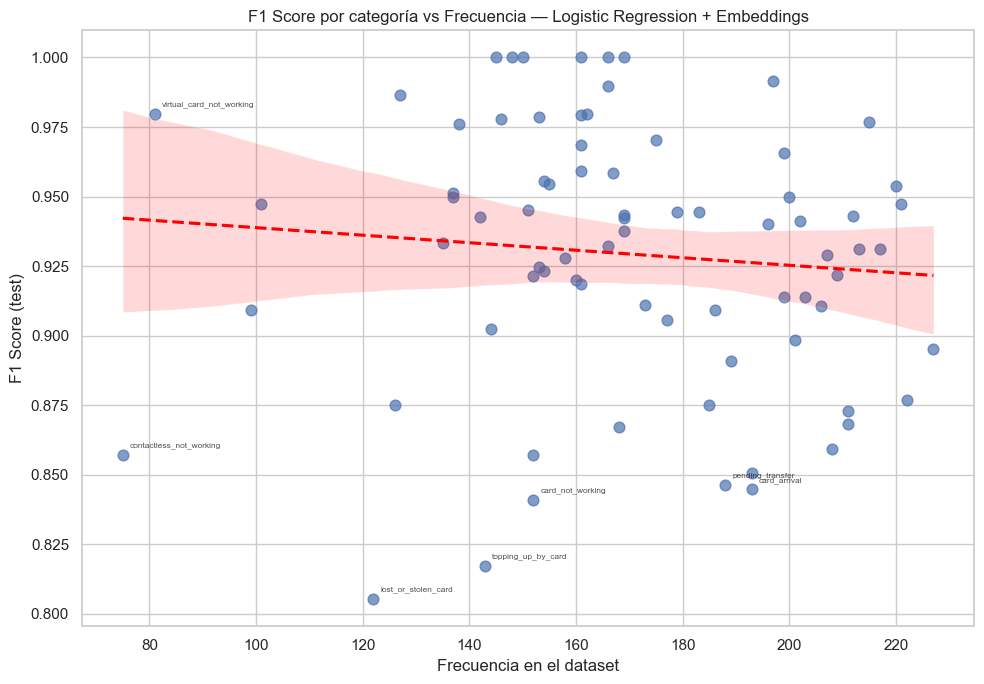

Correlación frecuencia vs F1: -0.095

Categorías con menor F1:


,category,freq,f1_score
42,lost_or_stolen_card,122,0.805195
62,topping_up_by_card,143,0.817204
15,card_not_working,152,0.840909
12,card_arrival,193,0.844828
49,pending_transfer,188,0.846154
26,declined_card_payment,193,0.850394
24,contactless_not_working,75,0.857143
13,card_delivery_estimate,152,0.857143
17,card_payment_not_recognised,208,0.859375
67,transfer_timing,168,0.867257


In [27]:
# F1 per-class vs frequency scatter plot
f1_per_class = f1_score(y_te, y_pred_best, average=None, zero_division=0)

cat_freqs = df['category'].value_counts()

per_class_df = pd.DataFrame({
    'category': le.classes_,
    'f1_score': f1_per_class,
})
per_class_df['freq'] = per_class_df['category'].map(cat_freqs)

fig, ax = plt.subplots(figsize=(10, 7))
sns.regplot(data=per_class_df, x='freq', y='f1_score', ax=ax,
            scatter_kws={'alpha': 0.7, 's': 60},
            line_kws={'color': 'red', 'linestyle': '--'})

for _, row in per_class_df.iterrows():
    if row['f1_score'] < 0.85 or row['freq'] < 90:
        ax.annotate(row['category'], (row['freq'], row['f1_score']),
                    fontsize=6, alpha=0.8,
                    xytext=(5, 5), textcoords='offset points')

ax.set_xlabel('Frecuencia en el dataset')
ax.set_ylabel('F1 Score (test)')
ax.set_title(f'F1 Score por categoría vs Frecuencia — {best_name} + {best_vec}')
plt.tight_layout()
plt.show()

corr = per_class_df['freq'].corr(per_class_df['f1_score'])
print(f'Correlación frecuencia vs F1: {corr:.3f}')
print(f'\nCategorías con menor F1:')
display(per_class_df.sort_values('f1_score').head(10)[['category', 'freq', 'f1_score']])


### 3.5 Alternativa sin SMOTE: `class_weight='balanced'`

In [28]:
lr_bal = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced', C=10)
lr_bal.fit(X_tfidf_train, y_train)
y_pred_cw = lr_bal.predict(X_tfidf_test)

acc_cw = accuracy_score(y_test, y_pred_cw)
f1w_cw = f1_score(y_test, y_pred_cw, average='weighted', zero_division=0)
f1m_cw = f1_score(y_test, y_pred_cw, average='macro', zero_division=0)

print('Logistic Regression + TF-IDF + class_weight="balanced"')
print(f'  Accuracy:    {acc_cw:.4f}')
print(f'  F1 weighted: {f1w_cw:.4f}')
print(f'  F1 macro:    {f1m_cw:.4f}')


Logistic Regression + TF-IDF + class_weight="balanced"
  Accuracy:    0.8680
  F1 weighted: 0.8685
  F1 macro:    0.8675
